     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for noise: filename=noise-1.2.2-cp312-cp312-linux_x86_64.whl size=56630 sha256=1f5765eeccb8445edb4cd704b7249d5cbc1388d9fab7d61edc3780e4474a330a
  Stored in directory: /root/.cache/pip/wheels/78/71/a2/47a0c6acdeb8f7a2f4e69067d3c737219e36414136441a1ef8
Successfully built noise


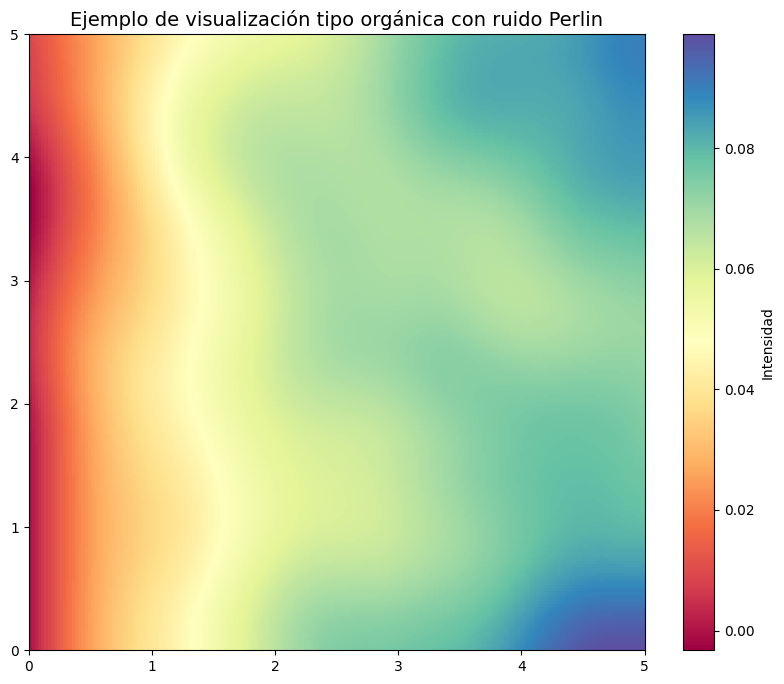

In [1]:
# Ejemplo de visualización tipo "orgánica" en Google Colab
# -------------------------------------------------------
# Se genera un mapa 3D con ruido Perlin, usando matplotlib y numpy

!pip install noise  # librería para generar ruido Perlin

import numpy as np
import matplotlib.pyplot as plt
from noise import pnoise2

# Parámetros del grid
n = 200
scale = 50.0

x = np.linspace(0, 5, n)
y = np.linspace(0, 5, n)
X, Y = np.meshgrid(x, y)

# Generamos ruido Perlin para simular textura orgánica
Z = np.zeros_like(X)
for i in range(n):
    for j in range(n):
        Z[i, j] = pnoise2(X[i, j] / scale, Y[i, j] / scale, octaves=6)

# Visualización con Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(Z, cmap="Spectral", origin="lower", extent=(0, 5, 0, 5))
plt.colorbar(label="Intensidad")
plt.title("Ejemplo de visualización tipo orgánica con ruido Perlin", fontsize=14)
plt.show()

In [2]:

# --- Visualización 3D interactiva tipo “orgánica” (Colab) ---
!pip -q install noise

import numpy as np
from noise import pnoise2
import plotly.graph_objects as go
import plotly.express as px

# Parámetros del grid y del ruido
n = 220            # resolución (puedes subir/bajar)
size_x, size_y = 6, 6
scale = 40.0       # más grande -> variaciones más suaves
octaves = 6        # más octavas -> más detalle
persistence = 0.5  # atenuación por octava
lacunarity = 2.0   # frecuencia por octava

x = np.linspace(0, size_x, n)
y = np.linspace(0, size_y, n)
X, Y = np.meshgrid(x, y)

# Ruido Perlin 2D
Z = np.zeros_like(X, dtype=float)
for i in range(n):
    for j in range(n):
        Z[i, j] = pnoise2(
            X[i, j] / scale,
            Y[i, j] / scale,
            octaves=octaves,
            persistence=persistence,
            lacunarity=lacunarity,
            repeatx=1024, repeaty=1024, base=0
        )

# --- Superficie 3D (rotar con arrastre, zoom con rueda/pinch) ---
fig = go.Figure(
    data=[go.Surface(z=Z, x=X, y=Y, colorscale="Turbo", showscale=True)]
)
fig.update_traces(
    contours_z=dict(show=True, usecolormap=True, highlightcolor="white", project_z=True),
    lighting=dict(ambient=0.7, diffuse=0.6, specular=0.2, roughness=0.9)
)
fig.update_layout(
    title="Superficie 3D con ruido Perlin (arrastra para rotar, rueda para zoom)",
    scene=dict(
        xaxis_title="x", yaxis_title="y", zaxis_title="z",
        aspectmode="data"
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show(config={"scrollZoom": True})  # habilita zoom con scroll

# --- Mapa 2D con zoom/pan (útil para “moverse” en el mapa) ---
fig2 = px.imshow(Z, origin="lower", color_continuous_scale="Turbo", aspect="equal")
fig2.update_layout(
    title="Mapa 2D interactivo (arrastra para pan, rueda para zoom)",
    xaxis_title="x", yaxis_title="y",
)
fig2.show(config={"scrollZoom": True})

Output hidden; open in https://colab.research.google.com to view.

In [3]:
# --- Visualización 3D con relieve pronunciado ---
!pip -q install noise

import numpy as np
from noise import pnoise2
import plotly.graph_objects as go

# Parámetros del grid y ruido
n = 200
size_x, size_y = 8, 8
scale = 40.0
octaves = 6
persistence = 0.5
lacunarity = 2.0

x = np.linspace(0, size_x, n)
y = np.linspace(0, size_y, n)
X, Y = np.meshgrid(x, y)

# Generamos ruido Perlin y lo amplificamos para el relieve
Z = np.zeros_like(X, dtype=float)
for i in range(n):
    for j in range(n):
        Z[i, j] = pnoise2(
            X[i, j] / scale,
            Y[i, j] / scale,
            octaves=octaves,
            persistence=persistence,
            lacunarity=lacunarity,
            repeatx=1024, repeaty=1024, base=0
        )

Z = Z * 20   # <<< factor de relieve, prueba con 10, 20, 50...

# --- Superficie 3D ---
fig = go.Figure(
    data=[go.Surface(
        z=Z, x=X, y=Y,
        colorscale="Viridis",
        showscale=True
    )]
)

# Ajustes de luz y vista
fig.update_traces(
    lighting=dict(ambient=0.4, diffuse=0.8, specular=0.5, roughness=0.7, fresnel=0.2),
    lightposition=dict(x=100, y=200, z=100)
)

fig.update_layout(
    title="Terreno con relieve generado con ruido Perlin",
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Altura",
        aspectmode="data"
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show(config={"scrollZoom": True})